In [1]:
# ==========================================
# Cell 1: Install / import dependencies
# ==========================================

from pathlib import Path
import sys

import matplotlib.pyplot as plt
from IPython.display import display

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd if (cwd / 'main.py').exists() else cwd.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from config import DEFAULT_SEED, make_params
from initialization import initialize_model
from main import run_one_round
from utils import set_random_seed
from visualization import (
    plot_final_opinion_distribution,
    plot_network_and_homophily,
    plot_opinion_leaders,
    plot_time_series_summaries,
    prepare_graph_for_visualization,
)


In [2]:
# ==========================================
# Cell 2: Random seed and helper functions
# ==========================================

SEED = DEFAULT_SEED
rng = set_random_seed(SEED)
SEED


42

In [3]:
# ==========================================
# Cell 3: Define model parameters
# ==========================================

params = make_params({
    "tolerance_threshold": 0.30,

    # 1. 先让初始分布更宽
    "opinion_std": 0.5,

    # 2. 降低冻结
    "tau_env": 0.90,
    "max_confidence": 15.0,

    # 3. 增强 out 区的强化/反弹
    "omega_pC_out": 0.12,
    "omega_pT_out": 0.04,
    "omega_nT_out": 0.10,
    "omega_nC_out": 0.00,

    # 4. 增加曝光
    "p_O": 0.04,
    "beta2_diff": 1.00,
    "max_read_capacity": 12,

    # 5. 把你之前加的 warmup 放松
    "creation_warmup_rounds": 2,
    "stance_feedback_warmup_rounds": 4,
    "style_feedback_warmup_rounds": 4,
    "creation_warmup_floor": 0.80,
    "stance_feedback_floor": 0.70,
    "style_feedback_floor": 0.70,

    # 6. 让同温层重连更容易
    "theta_F": 2.8,
    "a4": 1.6,
    "b_O": 0.6,
    "b_TO": 1.0,
})


params


{'N': 2000,
 'm_BA': 3,
 'leader_in_degree_threshold': 20,
 'T_rounds': 30,
 'opinion_mean': 0.0,
 'opinion_std': 0.5,
 'Abar_low': 0.2,
 'Abar_high': 0.8,
 'rho_A': 0.6,
 'omega1': 0.1,
 'omega2': 0.2,
 'omega3': 0.05,
 'N_E': 10.0,
 'kappa': 2.0,
 'alpha0': -2.25,
 'alpha1': 1.8,
 'alpha2': 1.2,
 'alpha3': 0.25,
 'originator_prob_cap': 0.3,
 'alpha_B': 1.5,
 'beta1': 0.6,
 'beta2': 0.4,
 'beta3': 0.5,
 'beta4': 0.7,
 'c0': 0.55,
 'epsilon_std': 0.15,
 'epsilon_ambiguity': 0.5,
 'gamma0': 0.15,
 'gamma1': 0.55,
 'gamma2': 0.35,
 'gamma3': 0.45,
 'gamma4': 0.25,
 'c_C': 0.1,
 'eta_C_std': 0.12,
 'delta0': 0.05,
 'delta1': 0.55,
 'delta2': 0.45,
 'delta3': 0.4,
 'delta4': 0.3,
 'c_T': 0.18,
 'eta_T_std': 0.12,
 'p_O': 0.04,
 'beta0_diff': -3.2,
 'beta1_diff': 0.8,
 'beta2_diff': 1.0,
 'max_read_capacity': 12,
 'w_o': 1.0,
 'w_l': 1.5,
 'tolerance_threshold': 0.3,
 'tau_env': 0.9,
 'eta_expression': 1.0,
 'max_confidence': 15.0,
 'omega_pC_in': 0.05,
 'omega_pT_in': 0.01,
 'omega_nC_in':

In [4]:
# ==========================================
# Cell 4: Initialize BA network and agent states
# ==========================================

G, G_initial_undirected, agents, blocks, pos = initialize_model(params, seed=SEED)

print('Initialization finished.')
print(f"Nodes: {G.number_of_nodes()}")
print(f"Directed edges: {G.number_of_edges()}")
print(f"Opinion leaders: {agents['L'].sum()}")
agents.head()


Initialization finished.
Nodes: 2000
Directed edges: 5991
Opinion leaders: 13


,node,F_t,L,o_t,confidence,s_t,Abar,A_t,m_t,O_t,C_t,M_pC_prev,M_pT_prev,M_nC_prev,M_nT_prev
0,0,35,1,-0.727314,1.0,-1,0.456983,0.456983,-0.896604,0,0,0.0,0.0,0.0,0.0
1,1,17,0,-0.420730,1.0,-1,0.777281,0.777281,-0.686582,0,0,0.0,0.0,0.0,0.0
2,2,3,0,-0.137427,1.0,-1,0.623265,0.623265,-0.268136,0,0,0.0,0.0,0.0,0.0
3,3,35,1,0.389811,1.0,1,0.200764,0.200764,0.652489,0,0,0.0,0.0,0.0,0.0
4,4,74,1,-0.010673,1.0,-1,0.213968,0.213968,-0.021343,0,0,0.0,0.0,0.0,0.0


In [5]:
# ==========================================
# Cell 5: Define one-round simulation function
# ==========================================

# The one-round workflow now lives in the local project code
# so that the notebook and scripts share the same implementation.
run_one_round


<function main.run_one_round(graph, agents, blocks: 'dict', params: 'dict', rng, current_round: 'int' = 1)>

In [6]:
# ==========================================
# Cell 6: Run the simulation for multiple rounds
# ==========================================

round_records = []
all_posts_by_round = {}
all_exposure_sets_by_round = {}

for t in range(1, params['T_rounds'] + 1):
    # 注意这里必须显式加上 current_round=t
    G, agents, posts, exposure_sets, summary = run_one_round(G, agents, blocks, params, rng, current_round=t)
    summary['round'] = t
    round_records.append(summary)
    all_posts_by_round[t] = posts
    all_exposure_sets_by_round[t] = exposure_sets
    print(
        f"Round {t:02d} | "
        f"Creators={summary['actual_creators']:3d} | "
        f"Support={summary['support_posts']:3d} | "
        f"Oppose={summary['oppose_posts']:3d} | "
        f"Toxic={summary['toxic_posts']:3d} | "
        f"AvgExposure={summary['avg_exposure_size']:.2f} | "
        f"Edges={summary['edge_count']}"
    )

import pandas as pd
history_df = pd.DataFrame(round_records)
history_df

Round 01 | Creators=198 | Support=107 | Oppose= 91 | Toxic= 99 | AvgExposure=8.90 | Edges=6538
Round 02 | Creators=252 | Support=146 | Oppose=106 | Toxic=175 | AvgExposure=10.55 | Edges=6793
Round 03 | Creators=199 | Support=109 | Oppose= 90 | Toxic=170 | AvgExposure=9.96 | Edges=7043
Round 04 | Creators=201 | Support=127 | Oppose= 74 | Toxic=185 | AvgExposure=8.80 | Edges=7149
Round 05 | Creators=213 | Support=163 | Oppose= 50 | Toxic=188 | AvgExposure=9.84 | Edges=7195
Round 06 | Creators=267 | Support=237 | Oppose= 30 | Toxic=229 | AvgExposure=10.95 | Edges=7264
Round 07 | Creators=309 | Support=282 | Oppose= 27 | Toxic=281 | AvgExposure=11.54 | Edges=7274
Round 08 | Creators=414 | Support=385 | Oppose= 29 | Toxic=358 | AvgExposure=11.96 | Edges=7317
Round 09 | Creators=265 | Support=240 | Oppose= 25 | Toxic=240 | AvgExposure=11.28 | Edges=7361
Round 10 | Creators=311 | Support=287 | Oppose= 24 | Toxic=286 | AvgExposure=11.58 | Edges=7361
Round 11 | Creators=379 | Support=349 | Oppo

,potential_originators,actual_creators,constructive_posts,toxic_posts,support_posts,oppose_posts,avg_exposure_size,mean_opinion,std_opinion,opinion_variance,extremist_ratio,homophily_ratio,sign_modularity,edge_count,round
0,531,198,99,99,107,91,8.8985,0.001395,0.504737,0.254632,0.2115,0.499541,-0.001220,6538,1
1,574,252,77,175,146,106,10.5525,0.002262,0.527727,0.278356,0.2460,0.511409,0.010912,6793,2
2,584,199,29,170,109,90,9.9555,0.003073,0.542416,0.294068,0.2715,0.520091,0.019035,7043,3
3,587,201,16,185,127,74,8.7970,0.002928,0.551528,0.304031,0.2880,0.523849,0.022902,7149,4
4,583,213,25,188,163,50,9.8390,0.003459,0.559352,0.312718,0.3035,0.524531,0.023510,7195,5
5,600,267,38,229,237,30,10.9475,0.003378,0.568944,0.323535,0.3160,0.528221,0.026423,7264,6
6,598,309,28,281,282,27,11.5395,0.003417,0.574953,0.330405,0.3215,0.529695,0.027013,7274,7
7,616,414,56,358,385,29,11.9610,0.002493,0.583821,0.340676,0.3365,0.530409,0.026882,7317,8
8,614,265,25,240,240,25,11.2820,0.002830,0.590420,0.348422,0.3460,0.534302,0.030853,7361,9
9,616,311,25,286,287,24,11.5845,0.003071,0.595306,0.354212,0.3520,0.534167,0.030315,7361,10


In [7]:
# ==========================================
# Cell 7: Show round-by-round summary
# ==========================================

display(history_df)


,potential_originators,actual_creators,constructive_posts,toxic_posts,support_posts,oppose_posts,avg_exposure_size,mean_opinion,std_opinion,opinion_variance,extremist_ratio,homophily_ratio,sign_modularity,edge_count,round
0,531,198,99,99,107,91,8.8985,0.001395,0.504737,0.254632,0.2115,0.499541,-0.001220,6538,1
1,574,252,77,175,146,106,10.5525,0.002262,0.527727,0.278356,0.2460,0.511409,0.010912,6793,2
2,584,199,29,170,109,90,9.9555,0.003073,0.542416,0.294068,0.2715,0.520091,0.019035,7043,3
3,587,201,16,185,127,74,8.7970,0.002928,0.551528,0.304031,0.2880,0.523849,0.022902,7149,4
4,583,213,25,188,163,50,9.8390,0.003459,0.559352,0.312718,0.3035,0.524531,0.023510,7195,5
5,600,267,38,229,237,30,10.9475,0.003378,0.568944,0.323535,0.3160,0.528221,0.026423,7264,6
6,598,309,28,281,282,27,11.5395,0.003417,0.574953,0.330405,0.3215,0.529695,0.027013,7274,7
7,616,414,56,358,385,29,11.9610,0.002493,0.583821,0.340676,0.3365,0.530409,0.026882,7317,8
8,614,265,25,240,240,25,11.2820,0.002830,0.590420,0.348422,0.3460,0.534302,0.030853,7361,9
9,616,311,25,286,287,24,11.5845,0.003071,0.595306,0.354212,0.3520,0.534167,0.030315,7361,10


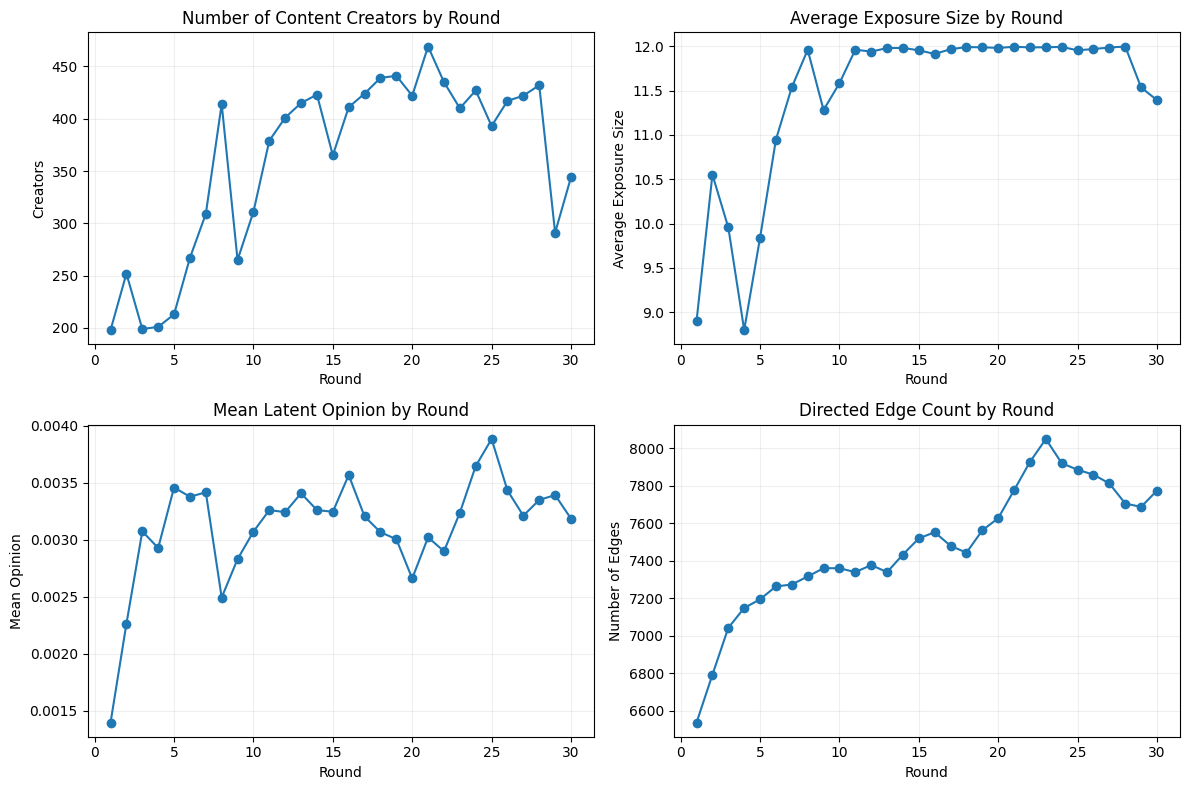

In [8]:
# ==========================================
# Cell 8: Plot time-series summaries over rounds
# ==========================================

fig, _ = plot_time_series_summaries(history_df)
plt.show()


In [9]:
# ==========================================
# Cell 9: Prepare final-round graph for visualization
# ==========================================

G_updated = prepare_graph_for_visualization(G, agents)
final_posts = all_posts_by_round[params['T_rounds']]
final_exposure_sets = all_exposure_sets_by_round[params['T_rounds']]

print('Final round prepared for visualization.')
print(f"Final number of edges: {G_updated.number_of_edges()}")


Final round prepared for visualization.
Final number of edges: 7775


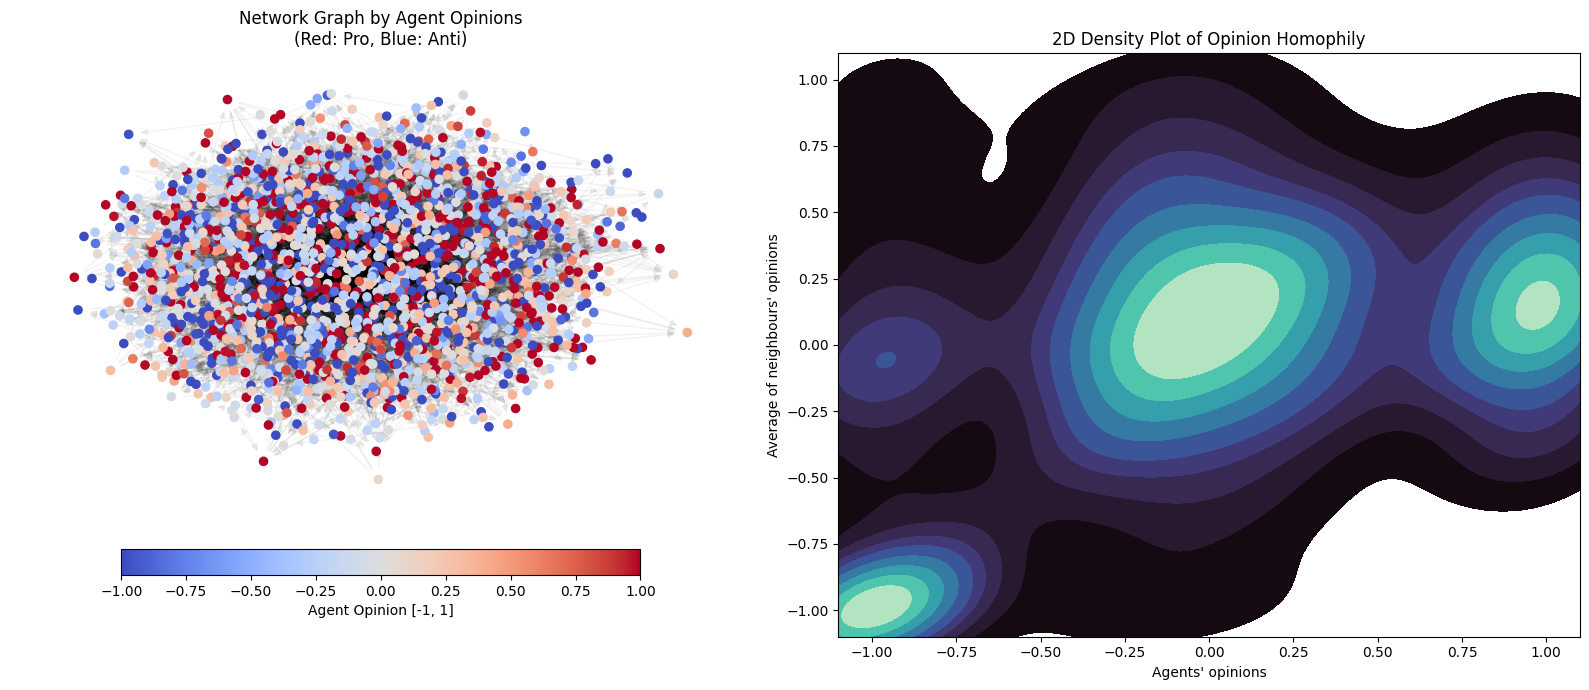

In [10]:
# ==========================================
# Cell 10: 1x2 visualization
# ==========================================

fig, _ = plot_network_and_homophily(G_updated, pos)
plt.show()


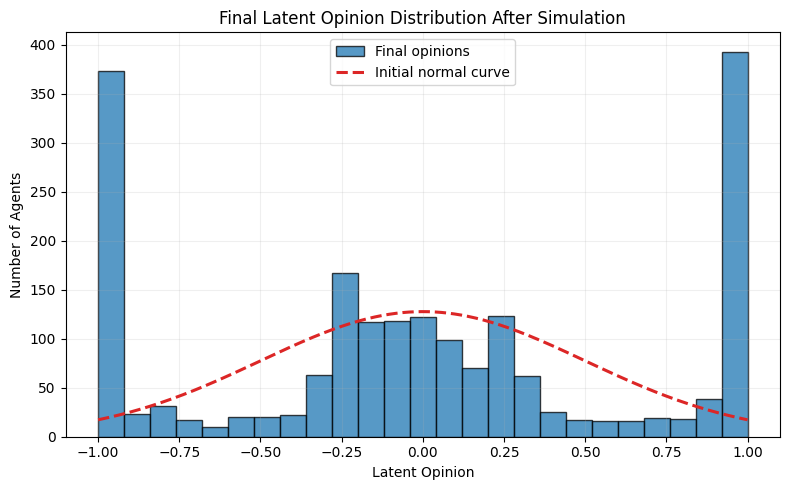

In [11]:
# ==========================================
# Cell 11: Final opinion distribution
# ==========================================

fig, _ = plot_final_opinion_distribution(agents, params=params)
plt.show()


/Users/paimon/projects/Opinion_ABM/visualization.py:162: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()
/Users/paimon/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


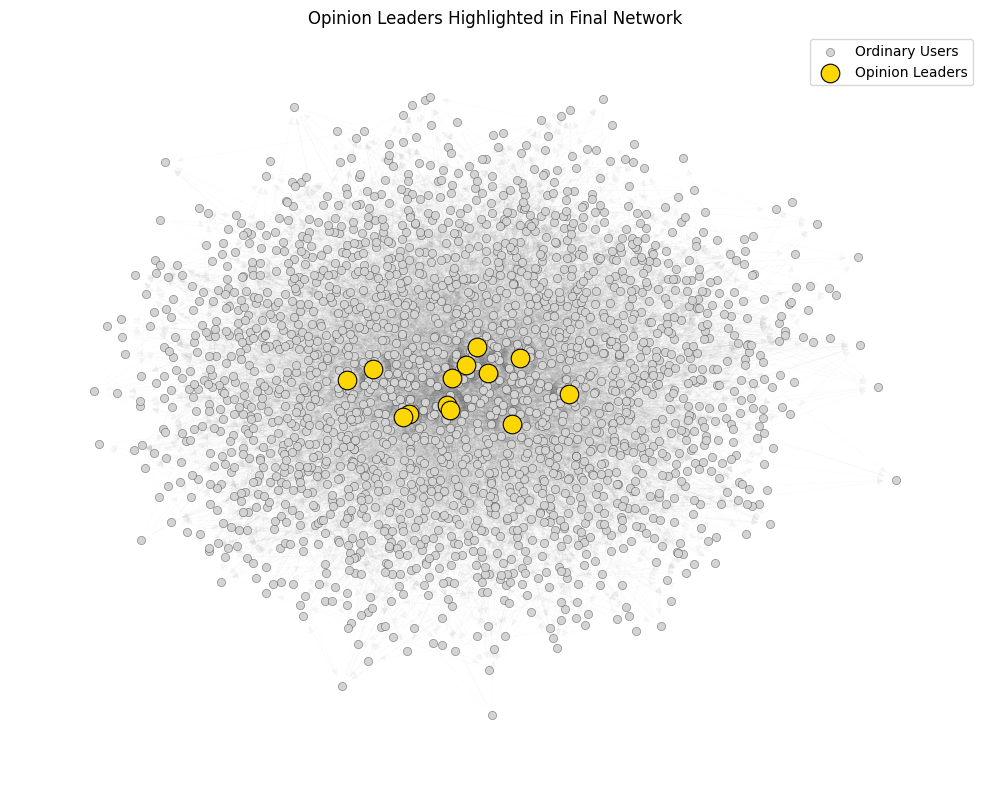

In [12]:
# ==========================================
# Cell 12: Highlight opinion leaders
# ==========================================

fig, _ = plot_opinion_leaders(G_updated, agents, pos)
plt.show()
